



## Introducción a la Programación Usando Modelos **Generativos**
<div style="border-style:groove;border-width:thin;padding:10px">

**Bibliografía:** Hands-On Generative AI with Transformers and Diffusion Models

#### Transformers y Modelos de Lenguaje, cómo funcionan por dentro
</div>

#### Zero-Shot generalization. Genralización zero-shot
<div style="border-style:groove;border-width:thin;padding:10px">

- La capacidad de un modelo de IA de resolver tareas o reconocer conceptos que nunca ha visto durante su entrenamiento, usando únicamente el conocimiento general que ya tiene.
- Ejemplo: En vez de entrenar un traductor, coges un modelo de lenguaje y pones el prompt "Traduce la siguiente frase de inglés a español: A yellow subnarine. Traducción:" Va a continuar la frase con la traducción. Eso es zero-shot, una generalización de sus funciones sin entrenamientos específicos.
- Los modelos actuales tienen una capacidad de realizar tareas para las que no han sido entrenados sorprendente.

</div>

#### Few-Shot Generalization

<div style="border-style:groove;border-width:thin;padding:10px">

- Alternativa al zero-shot: Guiar a un modelo dándole unos pocos ejemplos de la tarea que queremos que realice, sin necesidad de reentrenarlo.
- Funciona influyendo en la generación de texto: los ejemplos aumentan la probabilidad de que el modelo continúe siguiendo el mismo patrón y estructura que le mostramos.
- Se puede reforzar añadiendo una instrucción breve ("Traduce inglés a español") junto a los ejemplos, lo que mejora la calidad de los resultados.

</div>

#### Actividad Few-shot:
<div style="border-style:groove;border-width:thin;padding:10px">
<ol>
<li> Basándote en lo visto hasta ahora carga un modelo y prepararló para generar texto.</li>
<li> Crea un prompt que tenga 3 o 4 ejemplos de traducción de inglés a español muy breves.</li>
<li> Genera texto usando ese prompt para que traduzca una frase en inglés.
</ol>
</div>

In [ ]:
#Tu código


#### Como funcionan los trasnformers
<div style="border-style:groove;border-width:thin;padding:10px">

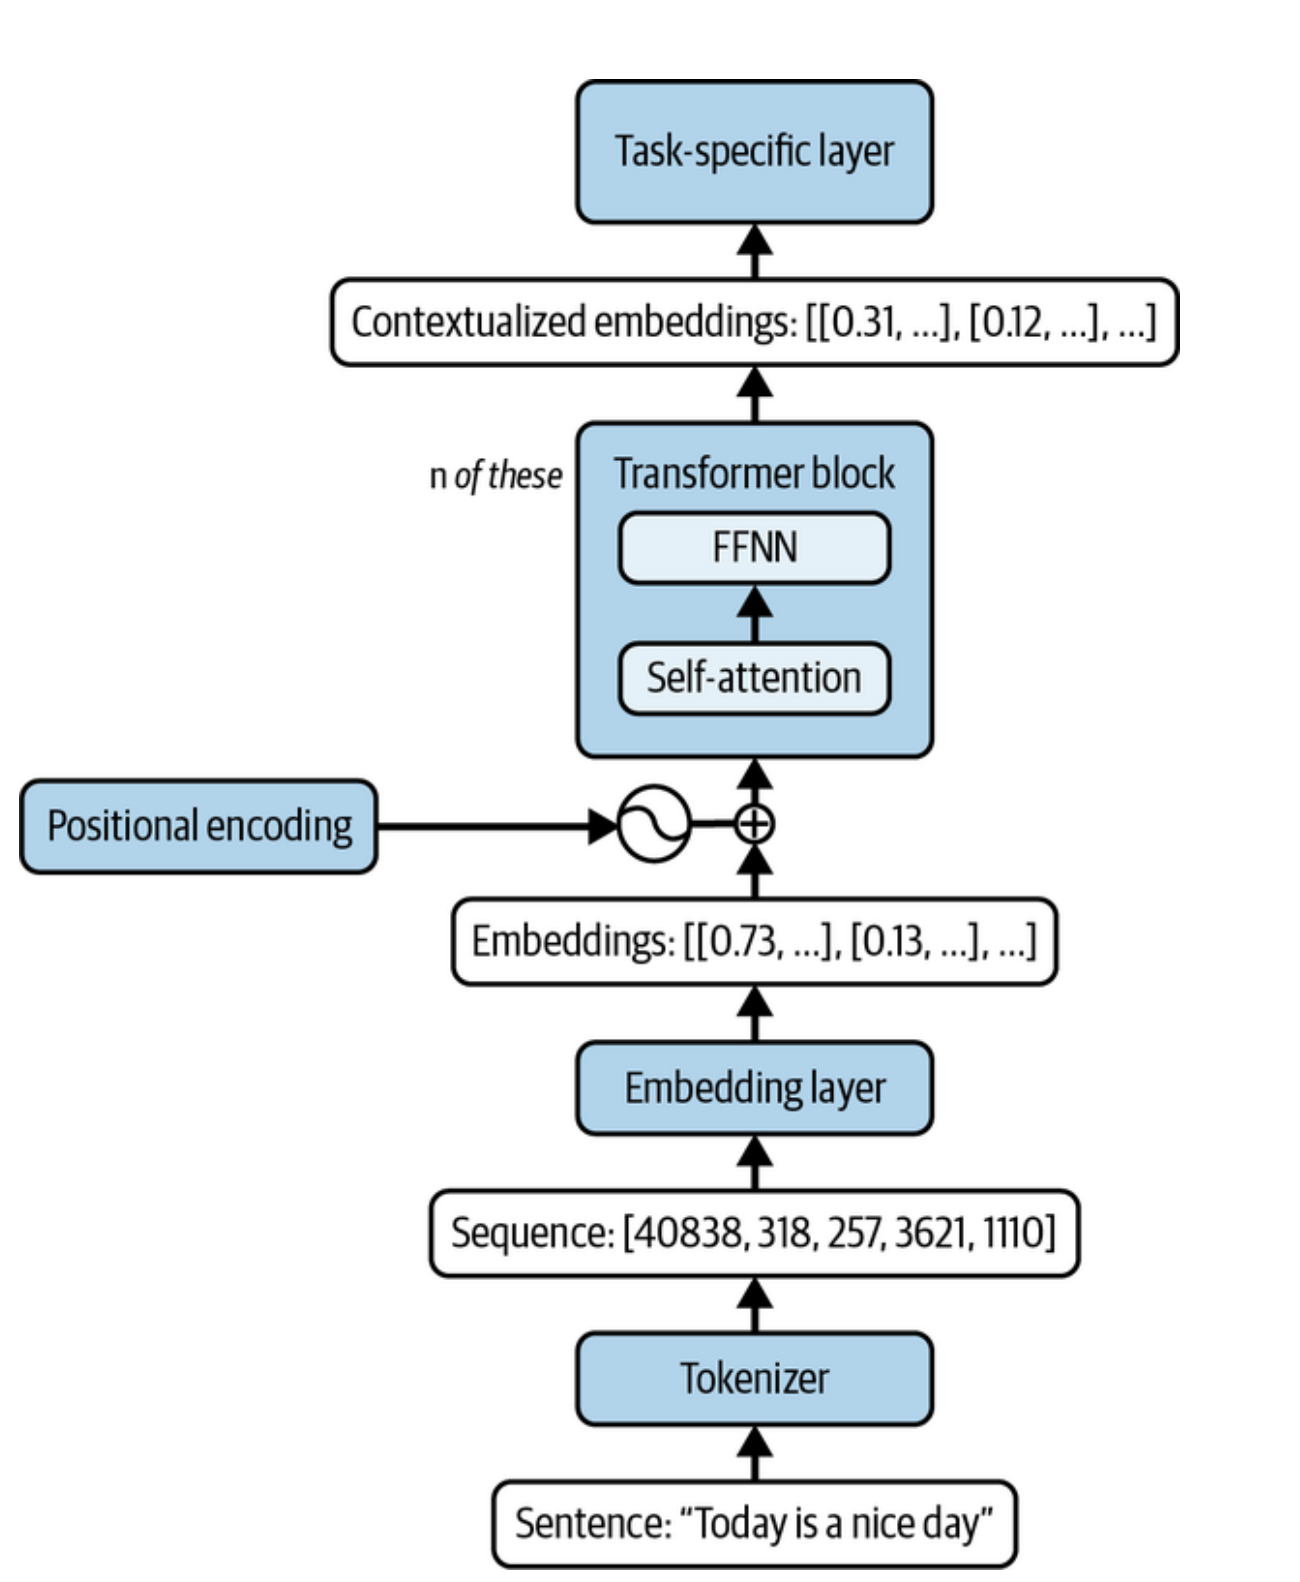

</div>

<div style="border-style:groove;border-width:thin;padding:10px">

#### Estructura del transformer
1. Se pasa el texto a tokens.
2. Cada token se representa con un "embedding". Son representaciones numéricas de la información del token. En la práctica son listas de números que tienen que ver con el significado de la palabra. A cada token le corresponde un embedding independientemente de donde esté en un texto.
3. Se añade el "positional encoding". Otro vector que contiene información sobre la posición del token en el texto.
4. Tras esto vienen los "Transformer blocks". Son el núcleo y suele tener varios. Es lo que permite al modelo establecer relaciones entre los tokens. Tiene 2 partes, el Self-attention mechanism, que permite establecer el peso de cada token dentro del texto y establecer relaciones entre los tokens, y la Feed-forward neural network, que refina la representación de la secuencia de entrada.
5. A la salida del transformer block tendremos un conjunto de embeddings de contexto que representan las relaciones entre los tokens. Ya no hay un embedding fijo por cada token sino que se van moldeando en función del contexto. Aquí ya tenemos información semántica compleja de los tokens y su contexto. 
6. Dependiendo de la tarea tendremos una capa final u otra. Sin embargo, todas ellas se fundamentan en la predicción. En generación de texto tendremos una red neuronal que acaba con una capa softmax para predecir el siguiente token.


</div>


#### Sequence-to-Sequence vs Encoder-only
<div style="border-style:groove;border-width:thin;padding:10px">

Arquitectura encoder-decoder: El transformer original (el del paper que los define) consta de dos bloques principales. El encoder procesa la secuencia de entrada y genera representaciones ricas de su significado. El decoder toma esas representaciones y genera la secuencia de salida, token por token. Este esquema —llamado sequence-to-sequence o seq2seq— es ideal para traducción, resumen o preguntas y respuestas. </br></br>
Cross-attention: El mecanismo que conecta ambos bloques se llama atención cruzada. Es similar a la auto-atención, pero en lugar de que cada token se fije en los demás tokens de su propia secuencia, se fija en la información que viene del encoder. Las capas de cross-attention se alternan con las de auto-atención en el decoder, combinando ambos contextos.
</div>

#### Tres familias de transformers: 
<div style="border-style:groove;border-width:thin;padding:10px">

El transformer original usaba encoder y decoder juntos, pero cada parte puede entrenarse de forma independiente, dando lugar a tres familias distintas:

- Encoder-Decoder (ej. BART, T5): ideales para traducción o resumen, convierten una secuencia completa en otra.

- Solo Decoder / Autoregresivos (ej. ChatGPT, Claude, Llama, Gemma): especializados en generación de texto, predicen el siguiente token basándose en los anteriores.


- Solo Encoder (ej. BERT): especializados en obtener representaciones ricas del texto, útiles para clasificación y búsqueda semántica.
</div>

#### ¿Por qué usar encoder-decoder si los modelos de solo decoder también funcionan bien? 

<div style="border-style:groove;border-width:thin;padding:10px">
Los modelos encoder-decoder están diseñados para traducir una secuencia entera de entrada a una de salida, lo que los hace naturalmente adecuados para esa tarea. Los modelos de solo decoder, en cambio, predicen token a token. Aunque modelos antiguos como GPT-2 eran menos capaces en tareas sin ejemplos (zero-shot), los modelos modernos como GPT-4 han cerrado esa brecha gracias a más datos, mejores técnicas de entrenamiento y mayor tamaño, volviéndose versátiles incluso en tareas que antes requerían arquitecturas seq2seq.
</div>

<div style="border-style:groove;border-width:thin;padding:10px">
Vamos a ver un ejemplo de encoder-only (pensado para interpretar texto, no para generar). En este código vamos a usar una clases que nos abstrae del proceso de tokenización, etc. Sería la clase pipeline de la librería transformers. 
</div>

In [1]:
#Código ejemplo de Enccoder-only

from transformers import pipeline
fill_masker = pipeline("fill-mask", model="bert-base-uncased")
fill_masker("The [MASK] is made of milk.")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

[{'score': 0.19546696543693542,
  'token': 9841,
  'token_str': 'dish',
  'sequence': 'the dish is made of milk.'},
 {'score': 0.1290753334760666,
  'token': 8808,
  'token_str': 'cheese',
  'sequence': 'the cheese is made of milk.'},
 {'score': 0.10590679198503494,
  'token': 6501,
  'token_str': 'milk',
  'sequence': 'the milk is made of milk.'},
 {'score': 0.041120853275060654,
  'token': 4392,
  'token_str': 'drink',
  'sequence': 'the drink is made of milk.'},
 {'score': 0.03712349385023117,
  'token': 7852,
  'token_str': 'bread',
  'sequence': 'the bread is made of milk.'}]

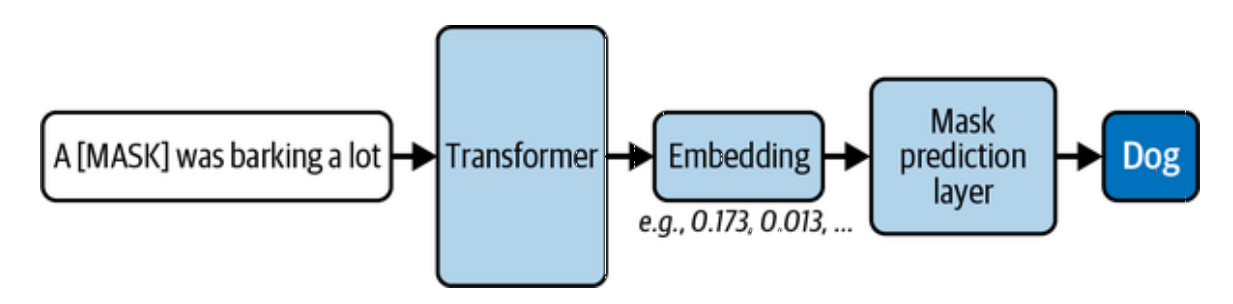

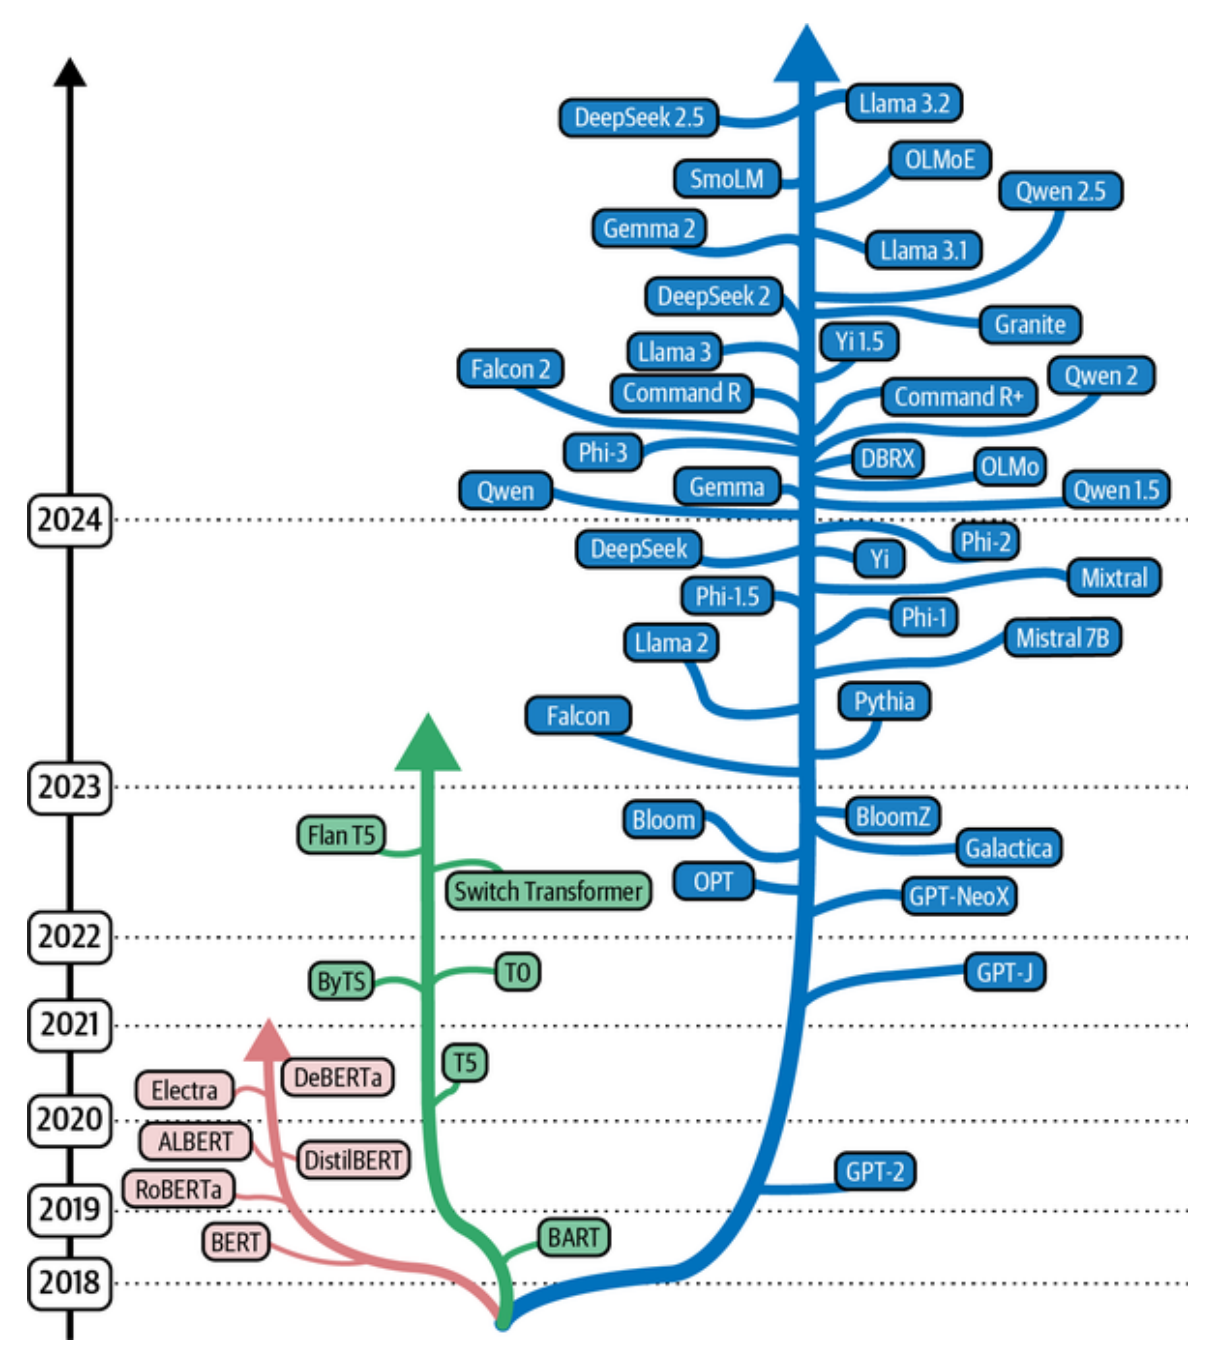

#### ¿Por qué funcionan tan bien los transformers? 

<div style="border-style:groove;border-width:thin;padding:10px">

- Mecanismo de atención: Permite al modelo relacionar tokens distantes entre sí, captando dependencias de largo alcance en el texto y estimando la relevancia de unos tokens respecto a otros.
- Escalabilidad: Su arquitectura está optimizada para la paralelización, lo que permite entrenarlos con datasets enormes y complejos. Además, aunque fueron diseñados para texto, son lo suficientemente flexibles para manejar otros tipos de datos.
- Preentrenamiento y fine-tuning (aprendizaje por transferencia): El enfoque tradicional de aprendizaje supervisado requería grandes cantidades de datos etiquetados, lo cual es caro y lento. La solución fue preentrenar un modelo con datos no etiquetados y luego ajustarlo (fine-tuning) para una tarea concreta con muchos menos datos etiquetados. Trabajos como ULMFiT demostraron que incluso preentrenar con texto genérico (como Wikipedia) daba excelentes resultados al ajustar el modelo para tareas específicas.

</div>

#### Preentrenamiento auto-supervisado 

<div style="border-style:groove;border-width:thin;padding:10px">

Con transformers como GPT, el modelo aprende a predecir el siguiente token sin necesidad de etiquetas: el propio texto es la fuente de supervisión. Con modelos de tipo BERT, se enmascaran tokens y el modelo aprende a reconstruirlos. En ambos casos, el modelo desarrolla una representación rica del lenguaje antes de ser ajustado.
</div>

#### ¿Cuándo usar cada tipo?

<div style="border-style:groove;border-width:thin;padding:10px">

- Modelos generativos (GPT): ideales para generación de texto.
- Modelos de encoder (BERT): ideales cuando se necesita una representación profunda del texto. Su capa final produce un embedding (representación densa) que puede usarse añadiendo una pequeña red encima para tareas como clasificación de sentimientos, reconocimiento de entidades, búsqueda semántica, preguntas y respuestas, sistemas de recomendación, entre otras.

</div>

#### Actividad transformers pipeline:
<div style="border-style:groove;border-width:thin;padding:10px">

Investiga que tareas o tasks se pueden hacer con la clase pipeline de transformers y haz una prueba con cada una.
</div>

In [5]:
#Tu código
from transformers.pipelines import SUPPORTED_TASKS

for task in SUPPORTED_TASKS.keys():
    print(task)

audio-classification
automatic-speech-recognition
text-to-audio
feature-extraction
text-classification
token-classification
table-question-answering
document-question-answering
fill-mask
text-generation
zero-shot-classification
zero-shot-image-classification
zero-shot-audio-classification
image-classification
image-feature-extraction
image-segmentation
image-text-to-text
object-detection
zero-shot-object-detection
depth-estimation
video-classification
mask-generation
keypoint-matching
any-to-any


In [3]:
from transformers import pipeline

# Ejemplo 1: análisis de sentimiento
classifier = pipeline("sentiment-analysis")

resultado = classifier("Me encanta aprender IA generativa")
print(resultado)

I0000 00:00:1777914271.907693   17236 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777914275.689153   17236 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777914283.811202   17236 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingfa

[{'label': 'POSITIVE', 'score': 0.9192185997962952}]


In [3]:
# Generación de texto
generator = pipeline("text-generation", model="gpt2")
print(generator("La inteligencia artificial", max_length=30))

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': 'La inteligencia artificial dell\'arte.\n\nPentagon, with the help of the Army Intelligence Headquarters (IA), launched a massive search of the planet\'s surface.\n\nA single asteroid, now known as a C-130 Hercules, flew over the planet\'s surface in what was believed to be a test launch.\n\nThe rocket exploded into the atmosphere and blasted off after only a few minutes of flying.\n\nAftermath\n\n"The C-130 Hercules was the most powerful rocket ever launched by the US government and the only one that could reach Earth\'s surface. It is a massive, massive success that will be remembered for all the people who were involved in it, and the people who had the chance to launch it."\n\nThe next day, the US government asked the public to share their opinions on the disaster.\n\nAn estimated 1 billion people died in the disaster.\n\nA small number of people were left homeless.\n\n"I think the entire nation of Vietnam was very happy about this, when they asked for their hel

In [14]:
# Traducción
translator = pipeline("translation_en_to_es", model="Helsinki-NLP/opus-mt-en-es")

print(translator("Machine learning is amazing"))

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


[{'translation_text': 'El aprendizaje automático es increíble'}]


In [5]:
# Resumen de texto
summarizer = pipeline("summarization", model="sshleifer/distilbart-cnn-12-6")

texto = """
Transformers are deep learning models widely used in NLP.
They can process long-range dependencies efficiently.
"""

print(summarizer(texto))

pytorch_model.bin:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.
Your max_length is set to 142, but your input_length is only 27. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=13)


model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

[{'summary_text': "Transformers are deep learning models widely used in NLP . They can process long-range dependencies efficiently .Transformers can be used to identify long-term dependencies and process them efficiently . They are also known as 'Transformers' and 'Neural' models for NLP applications ."}]


In [15]:
from transformers import pipeline

classifier = pipeline("zero-shot-classification")

texto = "I love programming neural networks"

labels = ["technology", "sports", "music", "politics"]

resultado = classifier(texto, labels)

print(resultado)

No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1 (https://huggingface.co/facebook/bart-large-mnli).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


{'sequence': 'I love programming neural networks', 'labels': ['technology', 'sports', 'music', 'politics'], 'scores': [0.986681342124939, 0.005716942250728607, 0.004334945231676102, 0.0032667226623743773]}


In [13]:
# !pip uninstall transformers -y
# !pip install transformers==4.46.0

In [1]:
import transformers

print(transformers.__version__)

4.46.0
